In [ ]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, print_metrics, plot_regression_results, evaluate_minirocket_vitaldb, train_mlp, select_top_pearson_features

In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=1000,
    STEP_SIZE=500
)

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_50%overlap/vitaldb_checkpoints"

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [02:28<00:00, 64.69it/s]


Skipped recordings: 81


100%|██████████| 1200/1200 [00:19<00:00, 62.10it/s]


Skipped recordings: 7


100%|██████████| 1200/1200 [00:19<00:00, 62.05it/s]


Skipped recordings: 9


In [4]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (829483, 1, 625)
y_train: (829483, 2)
X_val: (104736, 1, 625)
y_val: (104736, 2)
X_test: (105176, 1, 625)
y_test: (105176, 2)


In [5]:
from sktime.transformations.panel.rocket import MiniRocket

rocket = MiniRocket(num_kernels=5000, random_state=42)

rocket.fit(X_train)

MiniRocket(num_kernels=5000, random_state=42)

In [6]:
def transform_to_disk(rocket, X, path, bs=2000):
    d = rocket.transform(X[:2]).shape[1]
    out = np.lib.format.open_memmap(path, mode="w+", dtype=np.float32, shape=(len(X), d))
    for i in tqdm(range(0, len(X), bs)):
        out[i:i+bs] = rocket.transform(X[i:i+bs]).to_numpy(dtype=np.float32)
    out.flush()
    return out

transform_to_disk(rocket, X_train, "X_train_minirocket.npy")
transform_to_disk(rocket, X_val,   "X_val_minirocket.npy")
transform_to_disk(rocket, X_test,  "X_test_minirocket.npy")
del X_train, X_val, X_test; import gc; gc.collect()   # raw windows no longer needed

100%|██████████| 53/53 [00:49<00:00,  1.08it/s]


2549

In [7]:
X_train_rocket = np.load("X_train_minirocket.npy", mmap_mode="r")
X_val_rocket   = np.load("X_val_minirocket.npy",   mmap_mode="r")
X_test_rocket  = np.load("X_test_minirocket.npy",  mmap_mode="r")

In [8]:
y_train_sbp = y_train[:, 0]
y_train_dbp = y_train[:, 1]

y_val_sbp = y_val[:, 0]
y_val_dbp = y_val[:, 1]

y_test_sbp = y_test[:, 0]
y_test_dbp = y_test[:, 1]

## RIDGE REGRESSION ##

In [9]:
class RidgeModel:
    def __init__(s, mu, sd, W, ym, col): s.mu, s.sd, s.W, s.ym, s.col = mu, sd, W, ym, col
    def predict(s, X):
        X = np.asarray(X, dtype=np.float32)
        return ((X - s.mu) / s.sd) @ s.W[:, s.col] + s.ym[s.col]

def ridge_stats(X, Y, bs=5000):
    n, d = X.shape
    XtX = np.zeros((d, d)); Xty = np.zeros((d, Y.shape[1]))
    sx = np.zeros(d); sy = np.zeros(Y.shape[1])
    for i in tqdm(range(0, n, bs)):
        xb = np.asarray(X[i:i+bs], dtype=np.float64); yb = Y[i:i+bs].astype(np.float64)
        XtX += xb.T @ xb; Xty += xb.T @ yb; sx += xb.sum(0); sy += yb.sum(0)
    return XtX, Xty, sx, sy, n

def solve_ridge(stats, alpha):
    XtX, Xty, sx, sy, n = stats
    mu, ym = sx / n, sy / n
    C = XtX - n * np.outer(mu, mu)
    sd = np.sqrt(np.diag(C) / n); sd[sd == 0] = 1
    C = C / np.outer(sd, sd)
    c = (Xty - n * np.outer(mu, ym)) / sd[:, None]
    W = np.linalg.solve(C + alpha * np.eye(len(mu)), c)
    return mu.astype(np.float32), sd.astype(np.float32), W.astype(np.float32), ym.astype(np.float32)

stats = ridge_stats(X_train_rocket, y_train)

best = {}
for col, name in [(0, "SBP"), (1, "DBP")]:
    scores = {}
    for a in [0.01, 0.1, 1, 10, 100, 1000, 10000]:
        mu, sd, W, ym = solve_ridge(stats, a)
        m = RidgeModel(mu, sd, W, ym, col)
        pred = np.concatenate([m.predict(X_val_rocket[i:i+5000]) for i in range(0, len(X_val_rocket), 5000)])
        scores[a] = np.sqrt(np.mean((pred - y_val[:, col])**2))
    a_best = min(scores, key=scores.get)
    print(name, "best alpha:", a_best, "val RMSE:", scores[a_best])
    best[name] = RidgeModel(*solve_ridge(stats, a_best), col)

grid_ridge_sbp, grid_ridge_dbp = best["SBP"], best["DBP"]

100%|██████████| 166/166 [00:59<00:00,  2.79it/s]


SBP best alpha: 10000 val RMSE: 17.133852
DBP best alpha: 10000 val RMSE: 8.852424


In [10]:
def batch_predict(m, X, bs=5000):
    return np.concatenate([m.predict(X[i:i+bs]) for i in range(0, len(X), bs)])

y_pred_sbp = batch_predict(grid_ridge_sbp, X_test_rocket)
y_pred_dbp = batch_predict(grid_ridge_dbp, X_test_rocket)

In [11]:
print("MiniRocket + Ridge — SBP")
print("------------------------")
print_metrics(y_test_sbp, y_pred_sbp)

print("\nMiniRocket + Ridge — DBP")
print("------------------------")
print_metrics(y_test_dbp, y_pred_dbp)

MiniRocket + Ridge — SBP
------------------------
RMSE: 17.7871
MSE : 316.3795
R²  : 0.4006
MAE : 13.5939

MiniRocket + Ridge — DBP
------------------------
RMSE: 9.0517
MSE : 81.9335
R²  : 0.3455
MAE : 6.6192


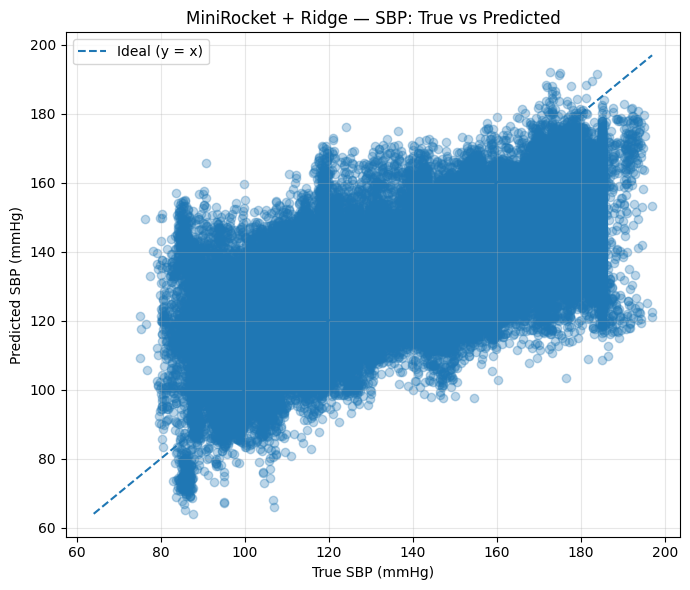

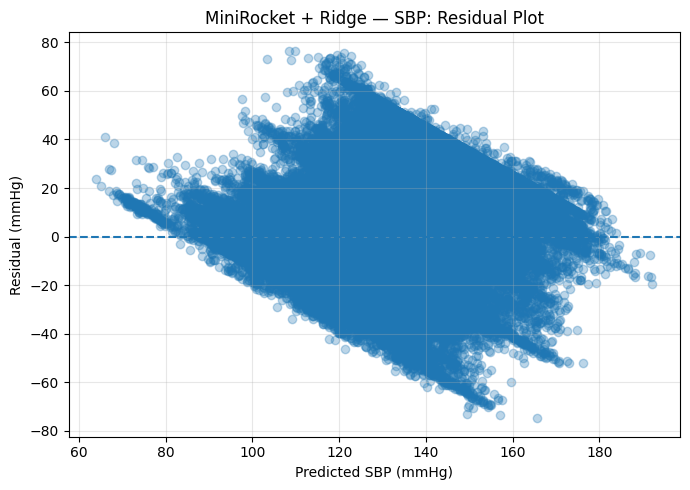

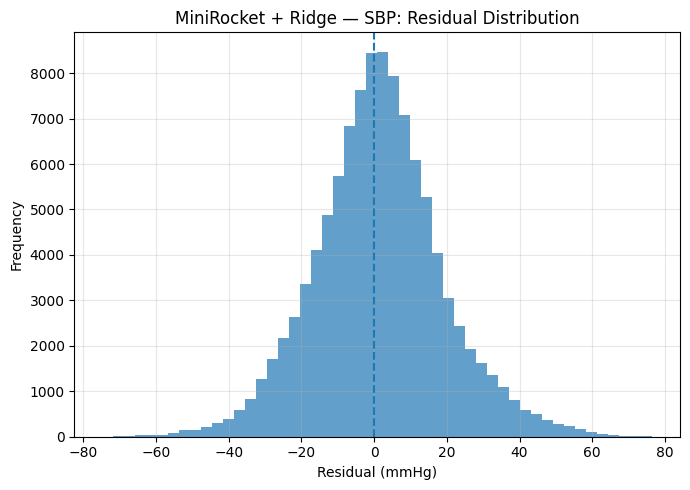

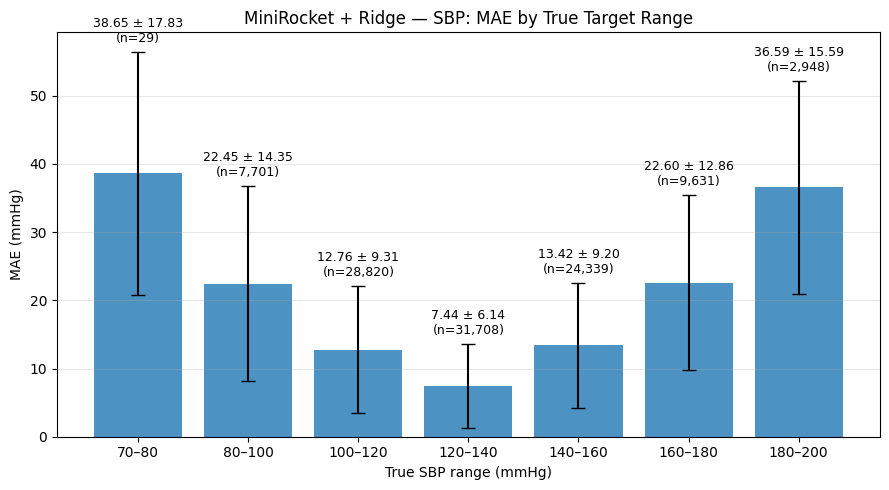

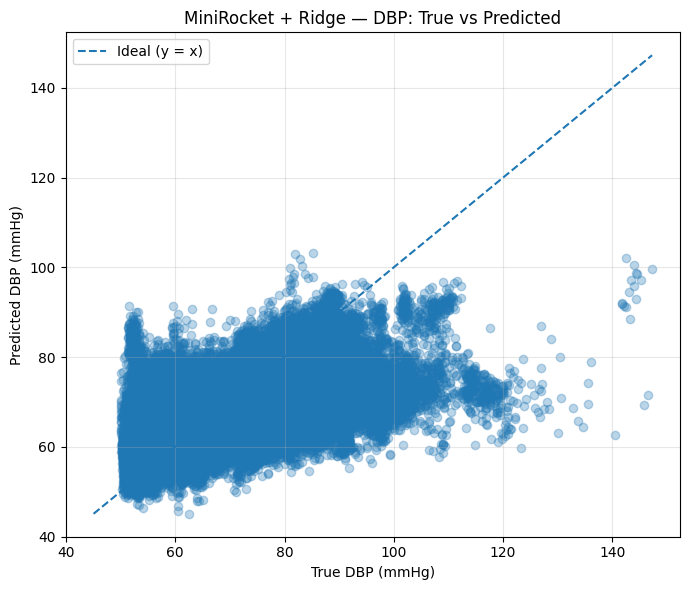

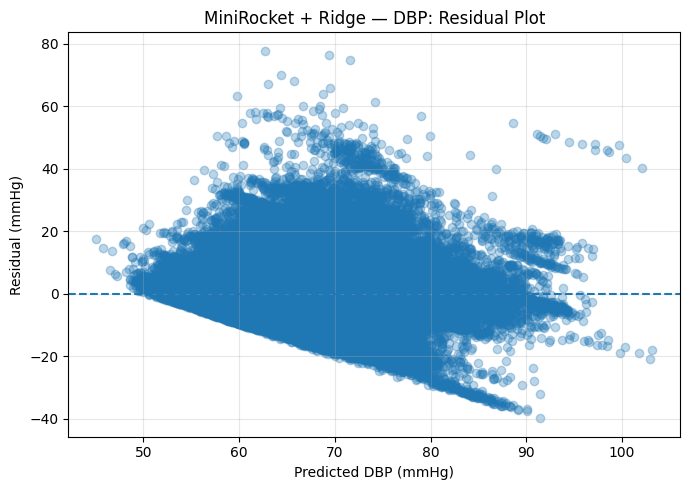

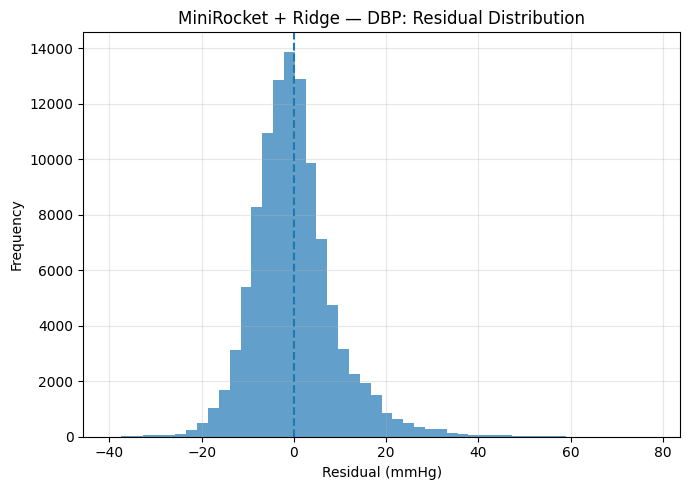

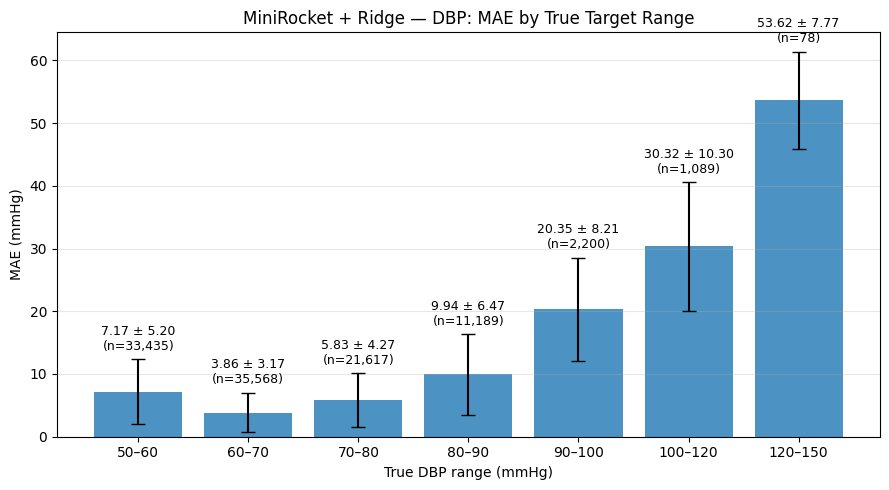

In [12]:
plot_regression_results(
    y_test_sbp,
    y_pred_sbp,
    "MiniRocket + Ridge",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_dbp,
    "MiniRocket + Ridge",
    "DBP"
)

Number of VitalDB cases: 1963


MiniROCKET VitalDB prediction: 100%|██████████| 1963/1963 [1:13:54<00:00,  2.26s/case]




MiniROCKET + Ridge
VITALDB ZERO-SHOT RESULTS

SBP
------------------------------
RMSE: 24.3032
MSE : 590.6444
R²  : -0.3819
MAE : 18.7943

DBP
------------------------------
RMSE: 14.1484
MSE : 200.1777
R²  : -0.2325
MAE : 11.0353


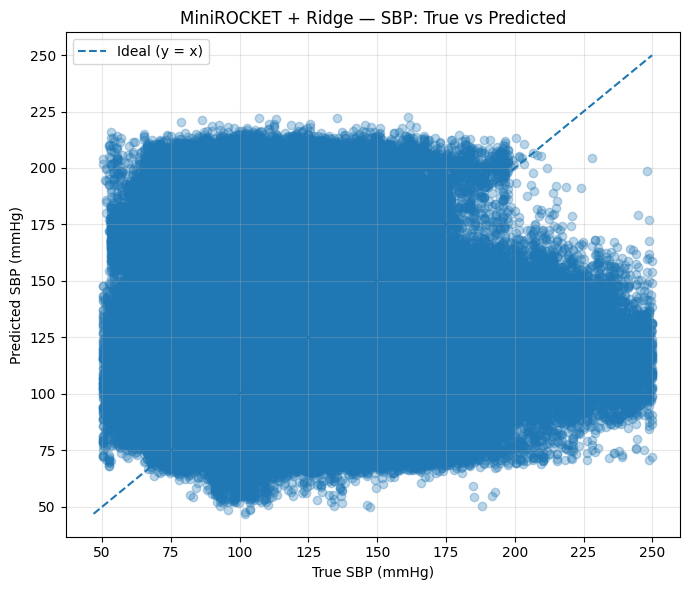

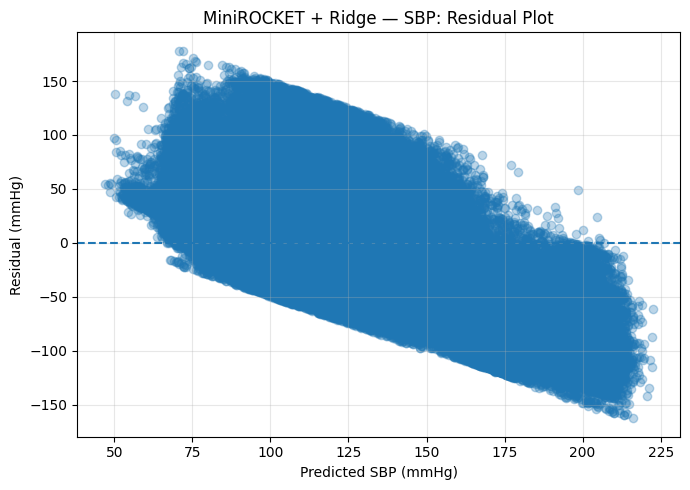

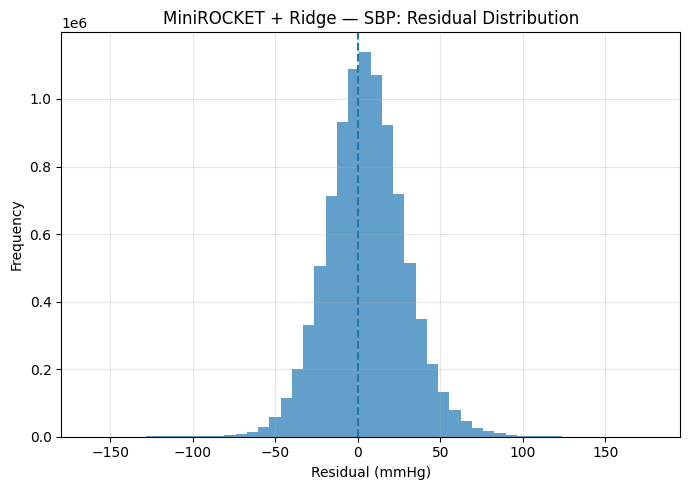

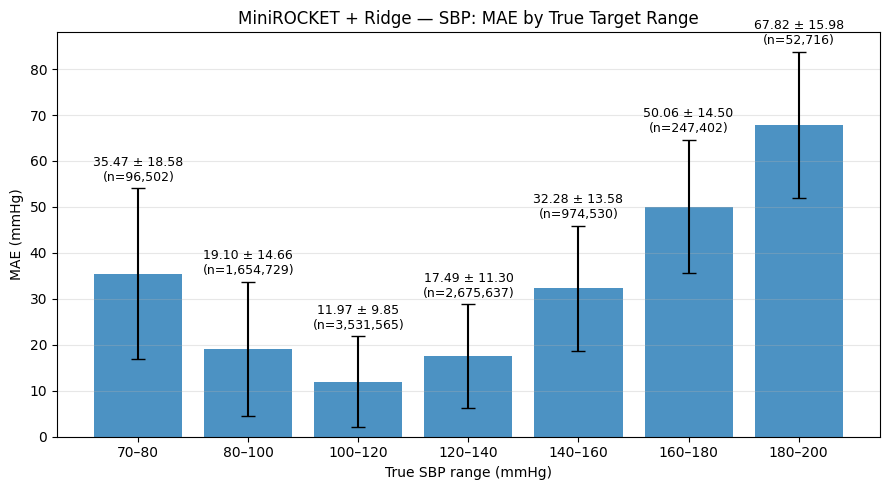

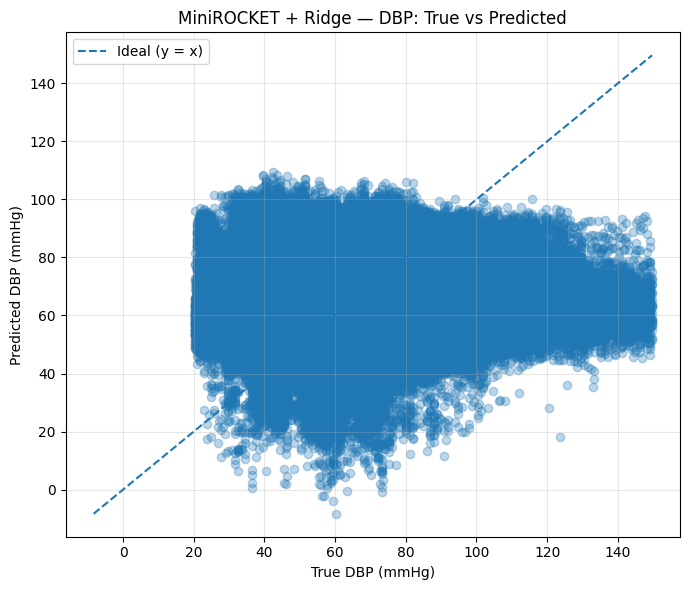

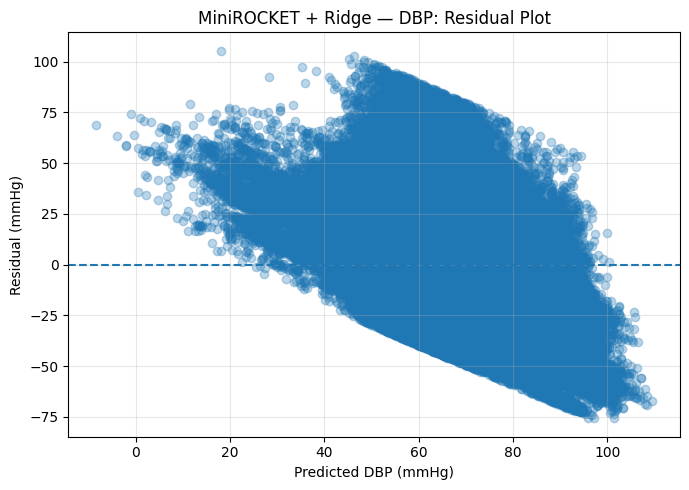

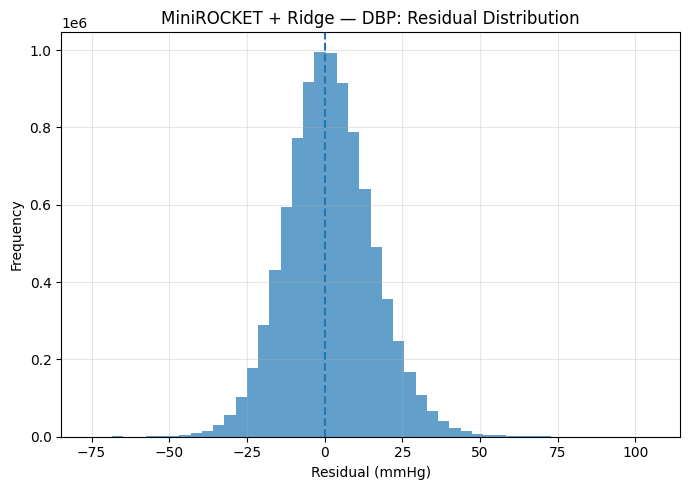

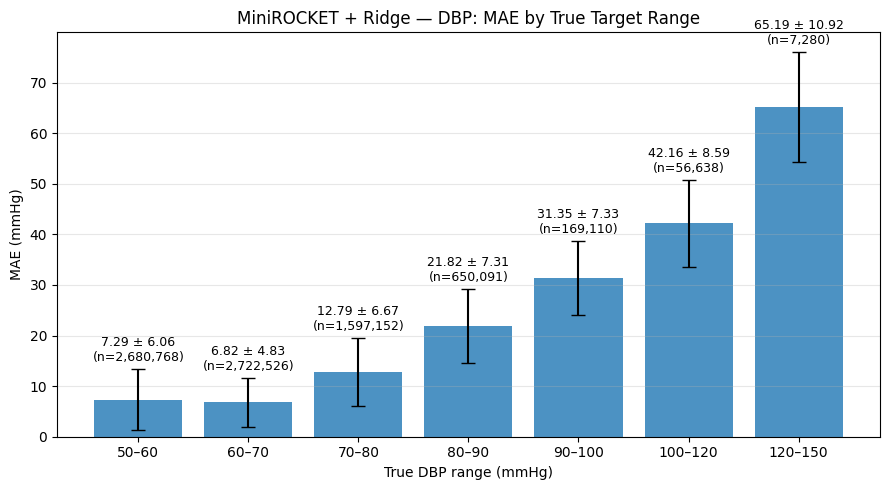


Final prediction shape:
(9271840, 5)

First 5 predictions:
  case_id    SBP_true    SBP_pred   DBP_true   DBP_pred
0  case_1  172.388672  119.588638  72.161774  51.714424
1  case_1  171.894928  118.938065  75.124176  50.504871
2  case_1  169.920013  113.449165  76.111603  53.304459
3  case_1  169.920013  114.332993  76.605347  54.417465
4  case_1  168.932587  120.317642  77.099091  53.122841


In [14]:
results_vitaldb = evaluate_minirocket_vitaldb(
    base_dir=BASE_DIR,
    rocket=rocket,
    best_en_sbp=grid_ridge_sbp,
    best_en_dbp=grid_ridge_dbp,
    model = "Ridge",
    batch_size=5000
)

## MLP ##

In [ ]:
mlp_sbp, mlp_dbp = train_mlp(X_train_rocket, y_train, X_val_rocket, y_val)

epoch 00 | TRAIN loss 0.2148 MSE(SBP 230.24, DBP 65.81) RMSE(SBP 15.17, DBP 8.11) | VAL loss 0.2538 MSE(SBP 283.85, DBP 74.69) RMSE(SBP 16.85, DBP 8.64)


epoch 01 | TRAIN loss 0.1812 MSE(SBP 186.80, DBP 56.26) RMSE(SBP 13.67, DBP 7.50) | VAL loss 0.2403 MSE(SBP 257.81, DBP 72.21) RMSE(SBP 16.06, DBP 8.50)


epoch 02 | TRAIN loss 0.1601 MSE(SBP 161.51, DBP 50.26) RMSE(SBP 12.71, DBP 7.09) | VAL loss 0.2291 MSE(SBP 240.80, DBP 69.15) RMSE(SBP 15.52, DBP 8.32)


epoch 03 | TRAIN loss 0.1499 MSE(SBP 151.06, DBP 47.05) RMSE(SBP 12.29, DBP 6.86) | VAL loss 0.2240 MSE(SBP 234.20, DBP 68.98) RMSE(SBP 15.30, DBP 8.31)


epoch 04 | TRAIN loss 0.1413 MSE(SBP 141.45, DBP 44.19) RMSE(SBP 11.89, DBP 6.65) | VAL loss 0.2191 MSE(SBP 233.72, DBP 65.79) RMSE(SBP 15.29, DBP 8.11)


In [ ]:
y_pred_sbp = batch_predict(mlp_sbp, X_test_rocket)
y_pred_dbp = batch_predict(mlp_dbp, X_test_rocket)
print_metrics(y_test[:, 0], y_pred_sbp)
print_metrics(y_test[:, 1], y_pred_dbp)

In [ ]:
plot_regression_results(
    y_test_sbp,
    y_pred_sbp,
    "MiniRocket + MLP",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_dbp,
    "MiniRocket + MLP",
    "DBP"
)

In [ ]:
results_vitaldb = evaluate_minirocket_vitaldb(
    base_dir=BASE_DIR, rocket=rocket,
    best_en_sbp=mlp_sbp, best_en_dbp=mlp_dbp, model = "MLP", batch_size=2000)

## Feature Selection ##

In [ ]:
sbp_idx, sbp_corr = select_top_pearson_features(
    X_train_rocket,
    y_train[:, 0],
    k=1000
)

dbp_idx, dbp_corr = select_top_pearson_features(
    X_train_rocket,
    y_train[:, 1],
    k=1000
)

In [ ]:
print("SBP top features:", sbp_idx[:20])
print("SBP correlations:", sbp_corr[:20])

print("DBP top features:", dbp_idx[:20])
print("DBP correlations:", dbp_corr[:20])